In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
import pickle
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix, precision_recall_curve

In [2]:
df = pd.read_csv("data/train.csv")
X = df['comment_text'].fillna(" ")
y = df.iloc[:, 2:]

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r"[^a-zA-Z']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [4]:
X = X.apply(clean_text)

In [5]:
MAX_NUM_WORDS = 50000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 100

In [6]:
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X)
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

In [7]:
embedding_index = {}
with open("glove/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

In [8]:
word_index = tokenizer.word_index
num_words = min(MAX_NUM_WORDS, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))
for word, i in word_index.items():
    if i >= MAX_NUM_WORDS:
        continue
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [9]:
model = Sequential([
    Embedding(num_words, EMBEDDING_DIM, weights=[embedding_matrix], input_length=MAX_SEQUENCE_LENGTH, trainable=False),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='sigmoid')
])

In [10]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model.fit(X_pad, y, batch_size=128, epochs=10, validation_split=0.1, callbacks=[early_stop])

Epoch 1/10
1122/1122 [==============================] - 607s 540ms/step - loss: 0.0901 - accuracy: 0.8397 - val_loss: 0.0646 - val_accuracy: 0.9940
Epoch 2/10
1122/1122 [==============================] - 629s 561ms/step - loss: 0.0636 - accuracy: 0.9849 - val_loss: 0.0561 - val_accuracy: 0.9940
Epoch 3/10
1122/1122 [==============================] - 639s 570ms/step - loss: 0.0598 - accuracy: 0.9856 - val_loss: 0.0542 - val_accuracy: 0.9940
Epoch 4/10
1122/1122 [==============================] - 630s 561ms/step - loss: 0.0568 - accuracy: 0.9879 - val_loss: 0.0524 - val_accuracy: 0.9940
Epoch 5/10
1122/1122 [==============================] - 648s 578ms/step - loss: 0.0553 - accuracy: 0.9832 - val_loss: 0.0518 - val_accuracy: 0.9940
Epoch 6/10
1122/1122 [==============================] - 668s 595ms/step - loss: 0.0538 - accuracy: 0.9859 - val_loss: 0.0520 - val_accuracy: 0.9940
Epoch 7/10
1122/1122 [==============================] - 677s 603ms/step - loss: 0.0526 - accuracy: 0.9833 - val_

In [12]:
model.save('lstm_toxicity_model3.h5')

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [13]:
model = load_model("lstm_toxicity_model3.h5")

In [14]:
# Predict on validation data to compute thresholds
y_pred = model.predict(X_pad)
optimal_thresholds = []
for i in range(6):
    precision, recall, thresholds = precision_recall_curve(y.values[:, i], y_pred[:, i])
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
    best_thresh = thresholds[np.argmax(f1)]
    optimal_thresholds.append(best_thresh)

4987/4987 [==============================] - 164s 33ms/step


In [15]:
# Binarize predictions using optimal thresholds
y_pred_binary = (y_pred > optimal_thresholds).astype(int)

In [16]:
# Multilabel confusion matrices
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
conf_matrices = multilabel_confusion_matrix(y, y_pred_binary)

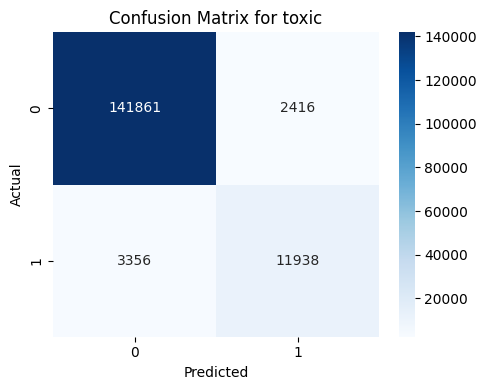

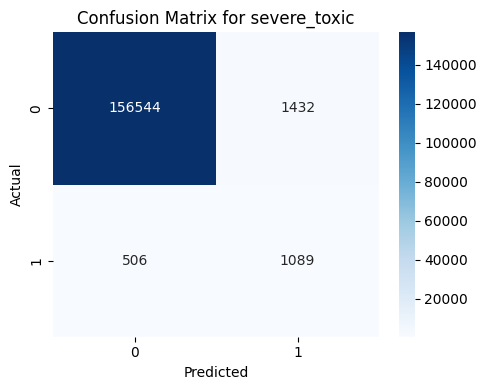

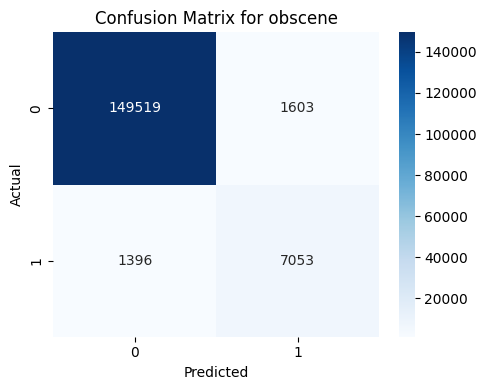

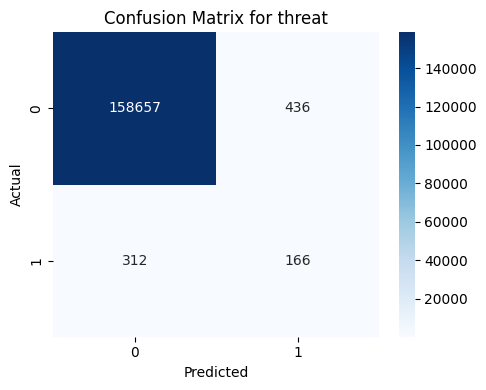

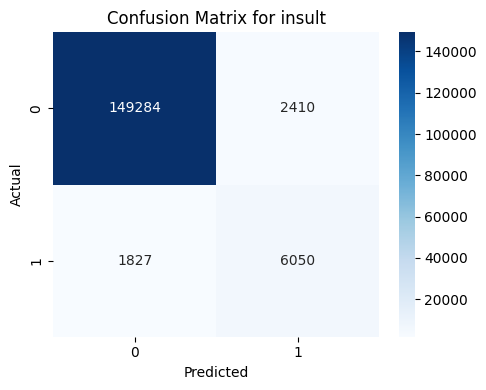

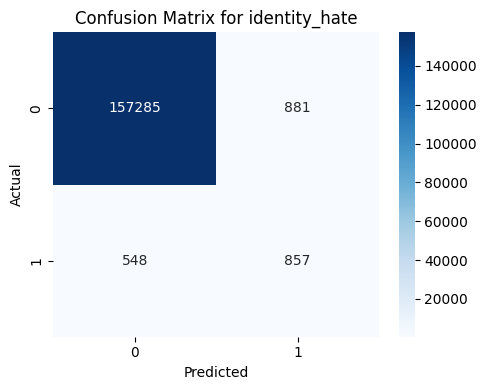

In [17]:
for i, label in enumerate(labels):
    plt.figure(figsize=(5,4))
    sns.heatmap(conf_matrices[i], annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {label}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [18]:
# Prediction function
def predict_toxicity(comment):
    with open('tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)

    def clean_text(text):
        text = text.lower()
        text = re.sub(r"http\S+|www\S+|https\S+", '', text)
        text = re.sub(r'<.*?>', '', text)
        text = re.sub(r"[^a-zA-Z']", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

In [19]:
def predict_toxicity(comment):
    with open('tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)

    def clean_text(text):
        text = text.lower()
        text = re.sub(r"http\S+|www\S+|https\S+", '', text)
        text = re.sub(r'<.*?>', '', text)
        text = re.sub(r"[^a-zA-Z']", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    comment = clean_text(comment)
    sequence = tokenizer.texts_to_sequences([comment])
    padded_sequence = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
    prediction = model.predict(padded_sequence)[0]
    result = [labels[i] for i in range(len(labels)) if prediction[i] > optimal_thresholds[i]]
    return "\n".join(result) if result else "No toxicity detected."

In [20]:
sample_comments = [
    "You are a terrible person.",
    "I love this!",
    "You're an idiot and ugly.",
    "Have a nice day!"
]

In [21]:
for comment in sample_comments:
    print(f"Comment: {comment}")
    print(f"Predicted Toxicity: {predict_toxicity(comment)}")
    print("="*50)

Comment: You are a terrible person.
1/1 [==============================] - 0s 18ms/step
Predicted Toxicity: toxic
Comment: I love this!
1/1 [==============================] - 0s 19ms/step
Predicted Toxicity: No toxicity detected.
Comment: You're an idiot and ugly.
1/1 [==============================] - 0s 22ms/step
Predicted Toxicity: toxic
obscene
insult
Comment: Have a nice day!
1/1 [==============================] - 0s 20ms/step
Predicted Toxicity: No toxicity detected.


In [23]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

# Calculate precision, recall, and F1 score using classification_report
report = classification_report(y, y_pred_binary, target_names=labels, zero_division=0)
print("Classification Report (Precision, Recall, F1 score):")
print(report)

# Alternatively, calculate precision, recall, and F1 manually for each label
precision, recall, f1, _ = precision_recall_fscore_support(y, y_pred_binary, average=None)
for i, label in enumerate(labels):
    print(f"Metrics for {label}:")
    print(f"Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1 score: {f1[i]:.4f}")
    print("-" * 50)

# If you'd like to compute a global average (macro or micro) for all labels:
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)

print(f"Macro Average Precision: {macro_precision:.4f}")
print(f"Macro Average Recall: {macro_recall:.4f}")
print(f"Macro Average F1 Score: {macro_f1:.4f}")


Classification Report (Precision, Recall, F1 score):
               precision    recall  f1-score   support

        toxic       0.83      0.78      0.81     15294
 severe_toxic       0.43      0.68      0.53      1595
      obscene       0.81      0.83      0.82      8449
       threat       0.28      0.35      0.31       478
       insult       0.72      0.77      0.74      7877
identity_hate       0.49      0.61      0.55      1405

    micro avg       0.75      0.77      0.76     35098
    macro avg       0.59      0.67      0.63     35098
 weighted avg       0.76      0.77      0.77     35098
  samples avg       0.06      0.07      0.06     35098

Metrics for toxic:
Precision: 0.8317, Recall: 0.7806, F1 score: 0.8053
--------------------------------------------------
Metrics for severe_toxic:
Precision: 0.4320, Recall: 0.6828, F1 score: 0.5292
--------------------------------------------------
Metrics for obscene:
Precision: 0.8148, Recall: 0.8348, F1 score: 0.8247
---------------

In [22]:
import gradio as gr

interface = gr.Interface(fn=predict_toxicity,
                         inputs=gr.Textbox(lines=2, placeholder='Enter a comment to analyze'),
                         outputs='text',
                         title="Toxic Comment Classifier",
                         description="Predicts which types of toxicity are present in a given comment.")
interface.launch()

* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


1/1 [==============================] - 0s 20ms/step
